In [1]:
#데이터 가져오기
from torchvision.datasets import FashionMNIST

#이미 나누어진 데이터 저장
raw_train = FashionMNIST(root="./data", train=True, download=True)
raw_test = FashionMNIST(root="./data", train=False, download=True)

#이미지 데이터와 정답 데이터 나누기
train_input = raw_train.data
train_target = raw_train.targets

#형태 확인
print(train_input.shape)
print(train_target.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


## 모델 구현

데이터 전처리

파이토치에서 Conv2d층은 입력을 (배치 크기, 채널 수, 높이, 너비)으로 받기에 형태 변환

또한 이미지 픽셀값을 0~1 사이로 바꿈.

CNN에 넣을 수 있도록 전처리된 이미지 데이터를 만드는 과정

In [2]:
#데이터 전처리
train_scaled = train_input.reshape(-1, 1, 28, 28) / 255.0

In [3]:
#훈련세트와 검증세트 나누기

from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled,
    train_target,
    test_size=0.2,
    random_state=42,
    stratify=train_target)

In [4]:
#합성곱층1
import torch.nn as nn

model = nn.Sequential()
model.add_module('conv1', nn.Conv2d(1, 32, kernel_size=3, padding='same'))
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(2))

In [5]:
#합성곱층2
model.add_module('conv2', nn.Conv2d(32, 64, kernel_size=3, padding='same'))
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(2))

#linear층에 넣기 위해 flatten 층
model.add_module('flatten', nn.Flatten())

In [6]:
#밀집층과 출력층
model.add_module('dense1', nn.Linear(3136, 100))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout())
model.add_module('dense2', nn.Linear(100, 10))

In [7]:
#손실함수와 옵티마이저 준비
import torch
import torch.optim as optim
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [8]:
#훈련세트와 검증세트로 각각 데이터셋을 만들고 이를 사용해 배치 크기 32인 데이터로더를 만드는 과정
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_scaled, train_target)
val_dataset = TensorDataset(val_scaled, val_target)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle= True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle= False)

In [9]:
train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0

epochs = 20
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss/len(train_loader)
    val_loss = val_loss/len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},",
          f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(model.state_dict(), 'best_cnn_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.6551, 검증 손실:0.3744
에포크:2, 훈련 손실:0.4332, 검증 손실:0.3060
에포크:3, 훈련 손실:0.3730, 검증 손실:0.2770
에포크:4, 훈련 손실:0.3358, 검증 손실:0.2579
에포크:5, 훈련 손실:0.3061, 검증 손실:0.2383
에포크:6, 훈련 손실:0.2843, 검증 손실:0.2401
에포크:7, 훈련 손실:0.2679, 검증 손실:0.2275
에포크:8, 훈련 손실:0.2477, 검증 손실:0.2326
에포크:9, 훈련 손실:0.2373, 검증 손실:0.2221
에포크:10, 훈련 손실:0.2201, 검증 손실:0.2225
에포크:11, 훈련 손실:0.2123, 검증 손실:0.2324
11번째 에포크에서 조기 종료되었습니다.


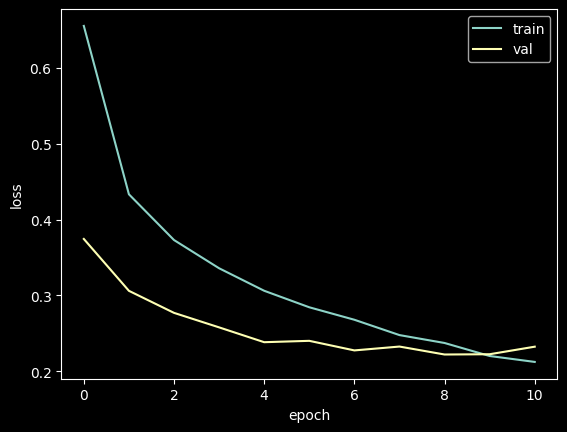

In [10]:
#훈련손실과 검증 손실을 그래프로 그리기
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [11]:
#훈련과정에 저장한 파일을 다시 로드하여 검증세트에 대한 정확도 확인
model.load_state_dict(torch.load('best_cnn_model.pt', weights_only=True))

model.eval()
corrects = 0
with torch.no_grad():
  for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            predicts = torch.argmax(outputs, 1)
            corrects += (predicts == targets).sum().item()

accuracy = corrects / len(val_dataset)
print(f"검증정확도: {accuracy:.4f}")

검증정확도: 0.9217


In [12]:
#테스트 세트에 대한 정확도 계산
test_scaled =raw_test.data.reshape(-1, 1, 28, 28) / 255.0
test_target = raw_test.targets

test_dataset = TensorDataset(test_scaled, test_target)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item()

accuracy = corrects / len(test_dataset)
print(f"테스트 정확도: {accuracy:.4f}")

테스트 정확도: 0.9121


# 기존 CNN 모델 개선해보기

기존 CNN

Input
→ Conv2d(1 → 32)
→ ReLU
→ MaxPool

→ Conv2d(32 → 64)
→ ReLU
→ MaxPool

→ Flatten
→ Linear(3136 → 100)
→ ReLU
→ Dropout
→ Linear(100 → 10)

--------
개선 CNN(목표로 하는 모델)

Input
→ Conv2d(1 → 32)
→ BatchNorm2d(32)
→ ReLU

→ Conv2d(32 → 32)
→ BatchNorm2d(32)
→ ReLU
→ MaxPool

→ Conv2d(32 → 64)
→ BatchNorm2d(64)
→ ReLU

→ Conv2d(64 → 64)
→ BatchNorm2d(64)
→ ReLU
→ MaxPool

→ Flatten
→ Linear(3136 → 128)
→ ReLU
→ Dropout
→ Linear(128 → 10)

BatchNorm을 넣어 각 층의 출력분포를 어느 정도 정리

In [17]:
#데이터 가져오기
from torchvision.datasets import FashionMNIST

#이미 나누어진 데이터 저장
raw_train = FashionMNIST(root="./data", train=True, download=True)
raw_test = FashionMNIST(root="./data", train=False, download=True)

#이미지 데이터와 정답 데이터 나누기
train_input = raw_train.data
train_target = raw_train.targets

#형태 확인
print(train_input.shape)
print(train_target.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


In [18]:
#데이터 전처리
train_scaled = train_input.reshape(-1, 1, 28, 28) / 255.0

In [19]:
print(train_scaled.shape)
print(train_target.shape)

#훈련세트와 검증세트 나누기
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled,
    train_target,
    test_size=0.2,
    random_state=42,
    stratify=train_target)

torch.Size([60000, 1, 28, 28])
torch.Size([60000])


In [20]:
#합성곱층
import torch.nn as nn

improved_model = nn.Sequential()

# 첫 번째 합성곱 블록
improved_model.add_module('conv1', nn.Conv2d(1, 32, kernel_size=3, padding='same'))
improved_model.add_module('bn1', nn.BatchNorm2d(32))
improved_model.add_module('relu1', nn.ReLU())

improved_model.add_module('conv2', nn.Conv2d(32, 32, kernel_size=3, padding='same'))
improved_model.add_module('bn2', nn.BatchNorm2d(32))
improved_model.add_module('relu2', nn.ReLU())
improved_model.add_module('pool1', nn.MaxPool2d(2))

In [21]:
# 두 번째 합성곱 블록
improved_model.add_module('conv3', nn.Conv2d(32, 64, kernel_size=3, padding='same'))
improved_model.add_module('bn3', nn.BatchNorm2d(64))
improved_model.add_module('relu3', nn.ReLU())

improved_model.add_module('conv4', nn.Conv2d(64, 64, kernel_size=3, padding='same'))
improved_model.add_module('bn4', nn.BatchNorm2d(64))
improved_model.add_module('relu4', nn.ReLU())
improved_model.add_module('pool2', nn.MaxPool2d(2))

In [22]:
#linear층에 넣기 위해 flatten 층
improved_model.add_module('flatten', nn.Flatten())

#밀집층과 출력층
improved_model.add_module('dense1', nn.Linear(64 * 7 * 7, 128))
improved_model.add_module('relu5', nn.ReLU())
improved_model.add_module('dropout', nn.Dropout(p=0.5))
improved_model.add_module('dense2', nn.Linear(128, 10))

In [23]:
#손실함수와 옵티마이저 준비
improved_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(improved_model.parameters())

In [24]:
# 훈련세트와 검증세트로 각각 데이터셋 만들기
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(train_scaled, train_target)
val_dataset = TensorDataset(val_scaled, val_target)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [25]:
#개선 모델 훈련
train_hist = []
val_hist = []
patience = 2
best_loss = -1
early_stopping_counter = 0

epochs = 20
for epoch in range(epochs):
    improved_model.train()
    train_loss = 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = improved_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    improved_model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = improved_model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    train_loss = train_loss/len(train_loader)
    val_loss = val_loss/len(val_loader)
    train_hist.append(train_loss)
    val_hist.append(val_loss)
    print(f"에포크:{epoch+1},",
          f"훈련 손실:{train_loss:.4f}, 검증 손실:{val_loss:.4f}")

    if best_loss == -1 or val_loss < best_loss:
        best_loss = val_loss
        early_stopping_counter = 0
        torch.save(improved_model.state_dict(), 'best_improved_cnn_model.pt')
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"{epoch+1}번째 에포크에서 조기 종료되었습니다.")
            break

에포크:1, 훈련 손실:0.4793, 검증 손실:0.2775
에포크:2, 훈련 손실:0.3311, 검증 손실:0.2483
에포크:3, 훈련 손실:0.2776, 검증 손실:0.2273
에포크:4, 훈련 손실:0.2480, 검증 손실:0.2132
에포크:5, 훈련 손실:0.2218, 검증 손실:0.2068
에포크:6, 훈련 손실:0.2028, 검증 손실:0.1993
에포크:7, 훈련 손실:0.1813, 검증 손실:0.1950
에포크:8, 훈련 손실:0.1665, 검증 손실:0.1936
에포크:9, 훈련 손실:0.1517, 검증 손실:0.1933
에포크:10, 훈련 손실:0.1379, 검증 손실:0.1872
에포크:11, 훈련 손실:0.1258, 검증 손실:0.1886
에포크:12, 훈련 손실:0.1139, 검증 손실:0.1918
12번째 에포크에서 조기 종료되었습니다.


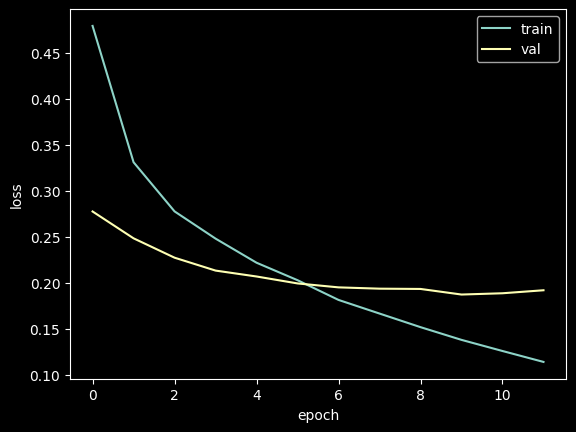

In [26]:
#훈련손실과 검증 손실을 그래프로 그리기
import matplotlib.pyplot as plt

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [27]:
#훈련과정에 저장한 파일을 다시 로드하여 검증세트에 대한 정확도 확인
improved_model.load_state_dict(torch.load('best_improved_cnn_model.pt', weights_only=True))

improved_model.eval()
corrects = 0
with torch.no_grad():
  for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = improved_model(inputs)
            predicts = torch.argmax(outputs, 1)
            corrects += (predicts == targets).sum().item()

accuracy = corrects / len(val_dataset)
print(f"검증정확도: {accuracy:.4f}")

검증정확도: 0.9385


In [28]:
#테스트 세트에 대한 정확도 계산
test_scaled =raw_test.data.reshape(-1, 1, 28, 28) / 255.0
test_target = raw_test.targets

test_dataset = TensorDataset(test_scaled, test_target)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

improved_model.eval()
corrects = 0
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = improved_model(inputs)
        predicts = torch.argmax(outputs, 1)
        corrects += (predicts == targets).sum().item()

accuracy = corrects / len(test_dataset)
print(f"테스트 정확도: {accuracy:.4f}")

테스트 정확도: 0.9309
